# Exploratory Data Analysis

本ノートブックでは、House Prices データセットの性質を体系的に確認し、
前処理・特徴量エンジニアリングの方針を整理する。

実際の分析では、まずベースラインの作成と特徴量の追加から着手し、
精度改善が頭打ちになった段階でデータの性質を改めて見直した。
本ノートブックは、その過程で行った探索的データ分析をテーマごとに整理している。

具体的には、以下の観点でデータを確認する。

- 目的変数 `SalePrice` の分布と、log変換の必要性
- 主要な数値変数と `SalePrice` の関係、および外れ値の有無
- 変数間の相関と、多重共線性の兆候
- 数値変数の歪度と、分布補正が必要な変数の洗い出し
- 欠損値の全体像
- `Neighborhood`（立地）による価格帯の違い

In [1]:
import sys
import warnings

sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

SEED = 123
from src.utils import seed_everything
seed_everything(SEED)

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

## 1. 目的変数 SalePrice の分布確認

モデルの学習・評価に使う目的変数の性質を最初に把握する。
分布が正規分布から大きく離れている場合、予測精度やモデルの安定性に影響するため、歪度・尖度を数値で確認した上で、ヒストグラムと Q-Q プロットで可視化する。

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.8829
Kurtosis: 6.5363


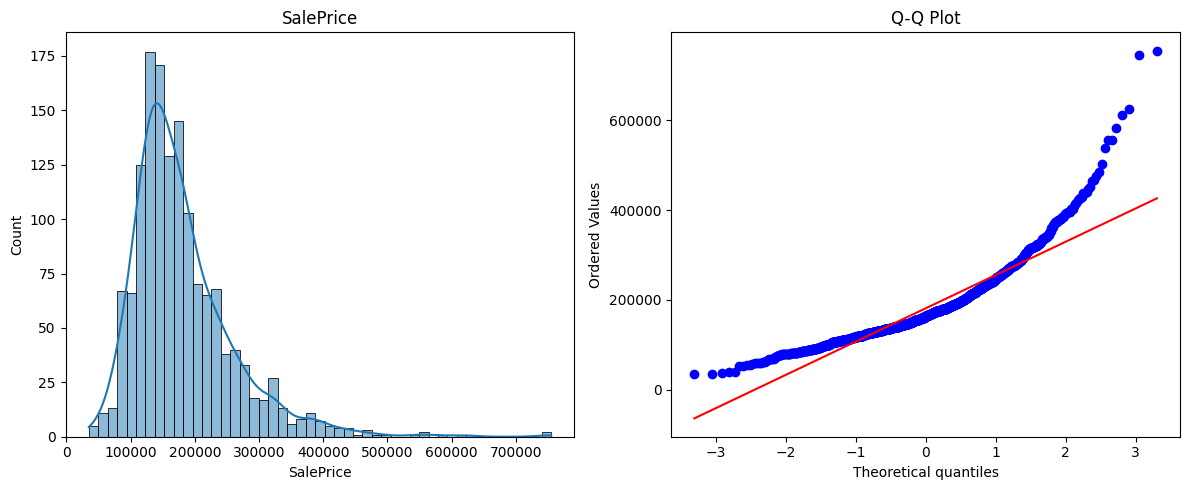

In [2]:
# SalePriceの基本統計
print(train_df['SalePrice'].describe())
print("\nSkewness: {:.4f}".format(train_df['SalePrice'].skew()))
print("Kurtosis: {:.4f}".format(train_df['SalePrice'].kurt()))

# 分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

stats.probplot(train_df['SalePrice'], plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()


* Skewness 1.88、Kurtosis 6.54 と、右に強く歪んでいて裾が重い分布であることが分かる。
* ヒストグラムでも右裾が長く伸びており、高額物件が少数だが存在する。
* Q-Q プロットは右端で直線から大きく外れており、正規分布からの乖離が明確である。

この分布のまま学習すると、高額物件に引っ張られて予測が不安定になる可能性がある。
log変換で分布を正規分布に近づけられるかを確認する。

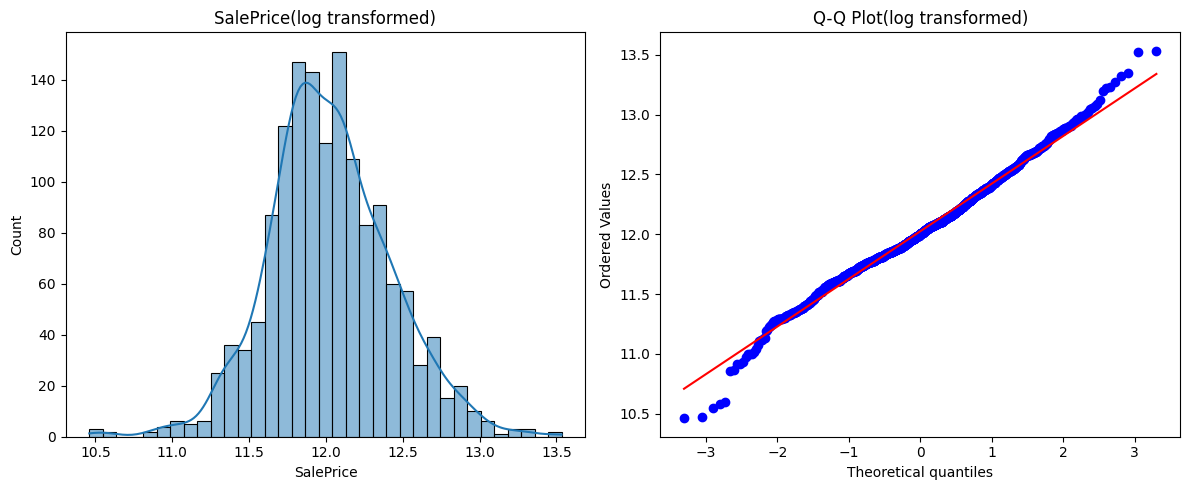

In [3]:
# log変換後の確認
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(np.log1p(train_df['SalePrice']), kde=True, ax=axes[0])
axes[0].set_title("SalePrice(log transformed)")

stats.probplot(np.log1p(train_df['SalePrice']), plot=axes[1])
axes[1].set_title("Q-Q Plot(log transformed)")

plt.tight_layout()
plt.show()


log変換後は、ヒストグラムがほぼ左右対称になり、Q-Q プロットも直線に近づいた。
この結果から、目的変数には `log1p` 変換を適用してモデルに渡す方針とする。

## 2. 主要変数と SalePrice の関係

目的変数の分布を確認したので、次に説明変数との関係を見る。
ここでは、`SalePrice` との相関が高いと想定される数値変数とカテゴリ変数をそれぞれ可視化し、傾向の強さと外れ値の有無を把握する。

### 2.1 数値変数との関係（GrLivArea, TotalBsmtSF）

地上居住面積（`GrLivArea`）と地下室面積（`TotalBsmtSF`）は、住宅の広さを代表する変数であり、価格との関係が強いと考えられる。
散布図で線形関係の有無と、外れ値の存在を確認する。

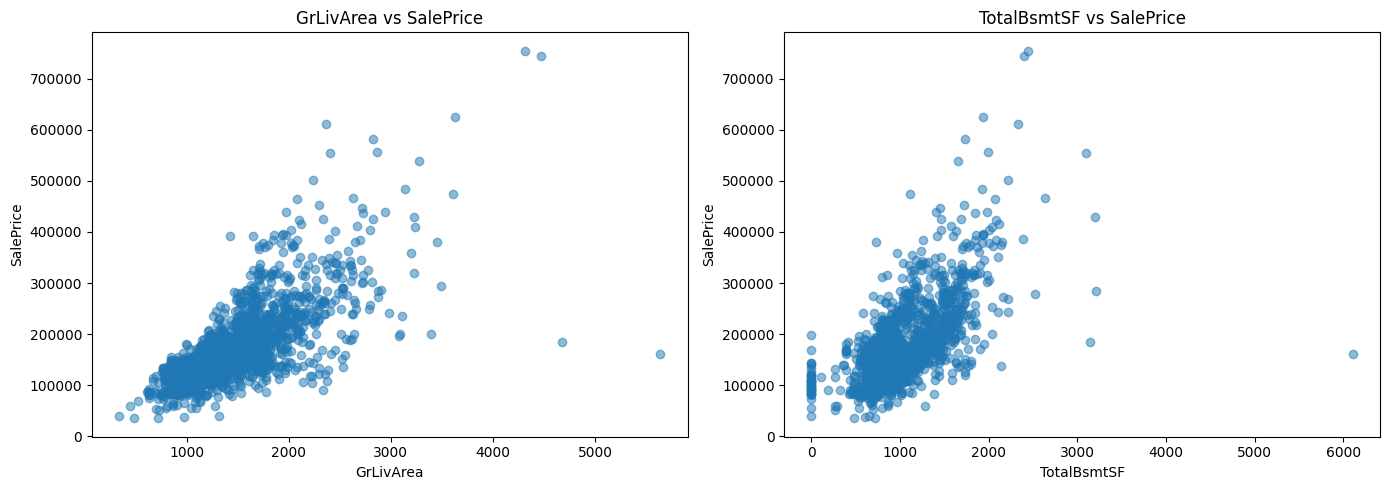

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice')

axes[1].scatter(train_df['TotalBsmtSF'], train_df['SalePrice'], alpha=0.5)
axes[1].set_xlabel('TotalBsmtSF')
axes[1].set_ylabel('SalePrice')
axes[1].set_title('TotalBsmtSF vs SalePrice')

plt.tight_layout()
plt.show()

- `GrLivArea` の散布図では、右下に 2 点、面積が 4000 超なのに価格が低い点が確認できる。
全体の傾向から明らかに外れており、外れ値候補として記録する。

- `TotalBsmtSF` では、x 軸の 0 付近に点が縦に並んでおり、地下室がない家が一定数存在することが分かる。
また、右端に 1 点だけ離れた点があり、こちらも外れ値候補である。

### 2.2 OverallQual との関係

`OverallQual`（全体品質スコア、1〜10）は、住宅の品質を総合的に示す変数である。
品質が高いほど価格も上がるという関係が成り立つかを boxplot で確認する。

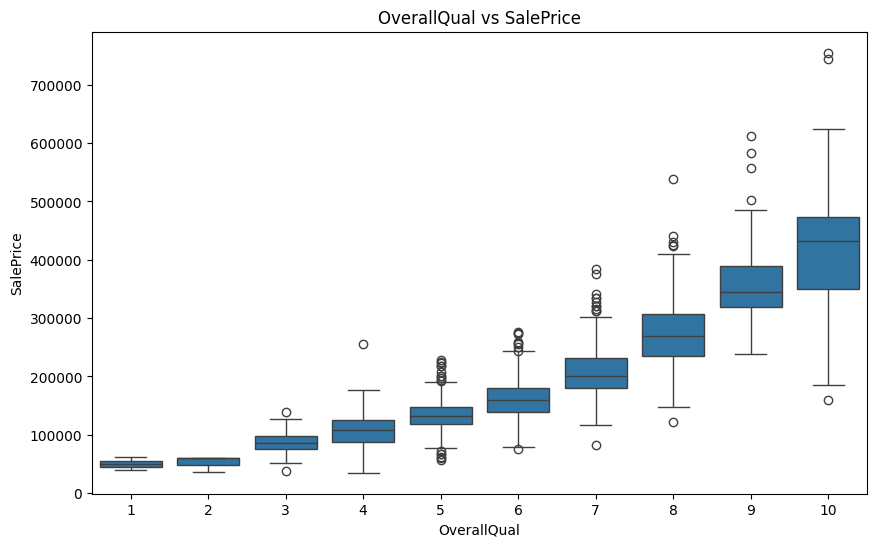

In [5]:
# OverallQualとSalePriceの関係をboxplotで確認
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train_df, ax=ax)
ax.set_title('OverallQual vs SalePrice')
plt.show()

- 品質スコアが 1 → 10 に上がるにつれて `SalePrice` も単調に上昇しており、`OverallQual` が価格予測において最も重要な変数の一つであることが確認できた。
特にスコア 8〜10 では価格の中央値・ばらつきともに大きくなり、高品質物件の価格帯の広さが分かる。

- 右上に `OverallQual` = 10 で 700,000 を超える 2 点があるが、品質 10 で高額になること自体は不自然ではないため、外れ値としては扱わない。

## 3. 変数間の相関

相関行列を使い、`SalePrice` と相関が強い変数の一覧を把握し、変数同士が似た情報を持っていないか（多重共線性）も確認する。

### 3.1 相関行列

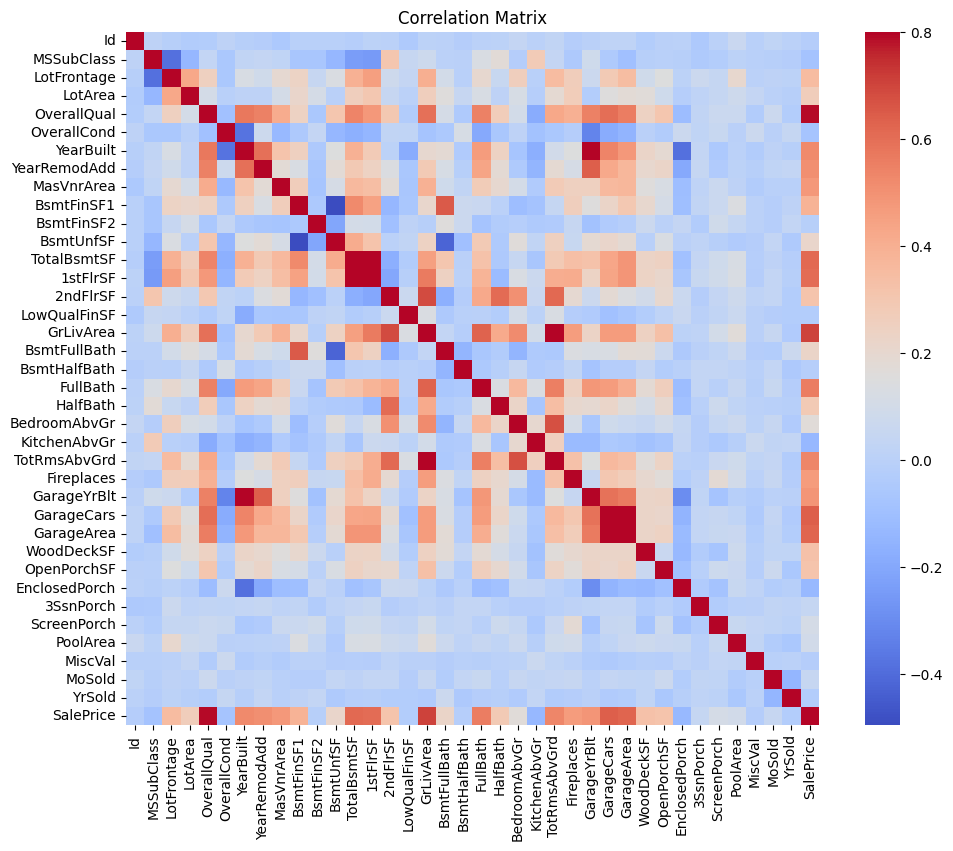

In [6]:
# 数値変数の相関行列をヒートマップで確認
# どの変数がSalePriceと強く相関しているかを一覧で見る
corrmat = train_df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=0.8, square=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- `SalePrice` の行を横に見ると、`OverallQual`、`GrLivArea`、`TotalBsmtSF`、`GarageCars`、`GarageArea` との相関が特に強いことが分かる。
これらは特徴量エンジニアリングで既に採用している変数であり、方向性が合っていることが確認できた。

- 対角線以外で赤い塊が 2 箇所ある。`GarageCars` × `GarageArea` と、`TotalBsmtSF` × `1stFlrSF` である。
これは多重共線性のサインであり、同じ情報を持つ変数が重複している可能性がある。
特徴量設計でこの点を考慮する必要がある。

### 3.2 SalePrice 上位変数の相関

全体の相関行列では個別の数値が読み取りにくいため、`SalePrice` との相関が高い上位 10 変数に絞って詳細を確認する。

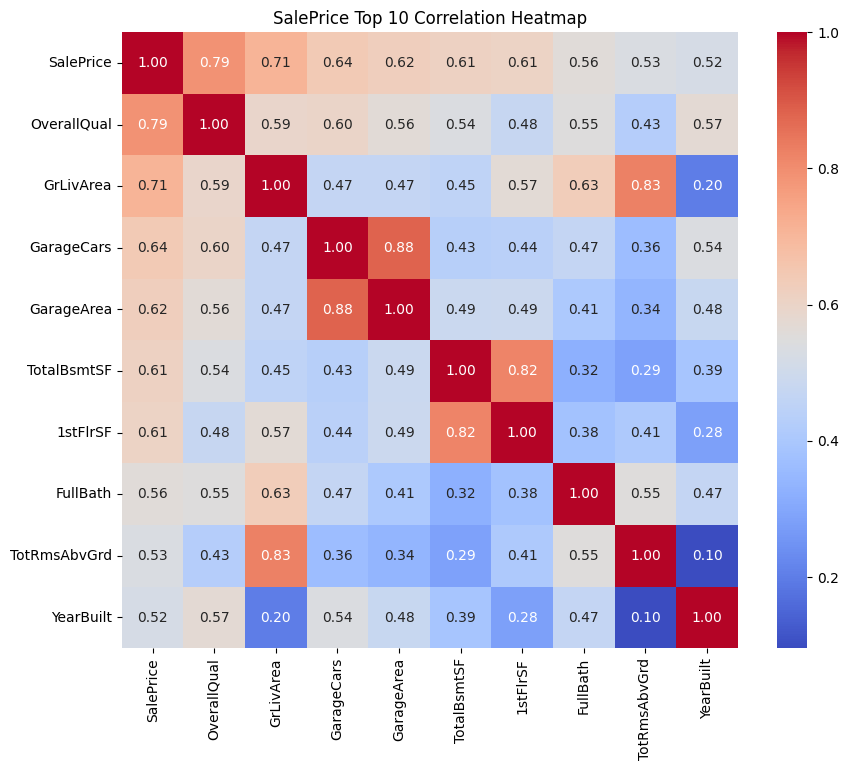

In [7]:
k = 10
cols = corrmat.nlargest(k, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(train_df[cols].values.T)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', square=True,
            yticklabels=cols.values, xticklabels=cols.values,
            cmap='coolwarm')
plt.title('SalePrice Top 10 Correlation Heatmap')
plt.show()

ヒートマップから、`SalePrice` との相関が特に強い上位 6 変数を抜き出して整理する。

| 順位 | 変数 | 相関係数 |
|---:|---|---:|
| 1 | OverallQual | 0.79 |
| 2 | GrLivArea | 0.71 |
| 3 | GarageCars | 0.64 |
| 4 | GarageArea | 0.62 |
| 5 | TotalBsmtSF | 0.61 |
| 6 | 1stFlrSF | 0.61 |

注目すべきは、`GarageCars` と `GarageArea` の相関が 0.88 と非常に高い点である。
ガレージの「台数」と「面積」はほぼ同じ情報を持っていると言える。
現在の `features` リストには両方が含まれており、さらに掛け算で作成した `GarageScore` も入っているが、特徴量重要度（`03_feature_engineering.ipynb` セクション5）では `GarageScore` が上位に入っており、モデルが有効に使い分けていることが確認できている。

また、`GrLivArea` と `TotRmsAbvGrd` の相関も 0.83 と高く、部屋数と面積が似た情報を持っている可能性がある。

`1stFlrSF` は `features` に含めていないが、`SalePrice` との相関は 0.61 ある。
ただし `TotalBsmtSF` との相関が 0.82 と高く、追加しても得られる情報は限定的と判断した。

## 4. 主要変数の関係を一覧で確認

これまで確認してきた主要変数について、pairplot で変数間の関係・分布・外れ値を一覧で確認する。
個別の散布図では見えなかった変数同士の関係や、確認済みの外れ値の再検出も目的とする。

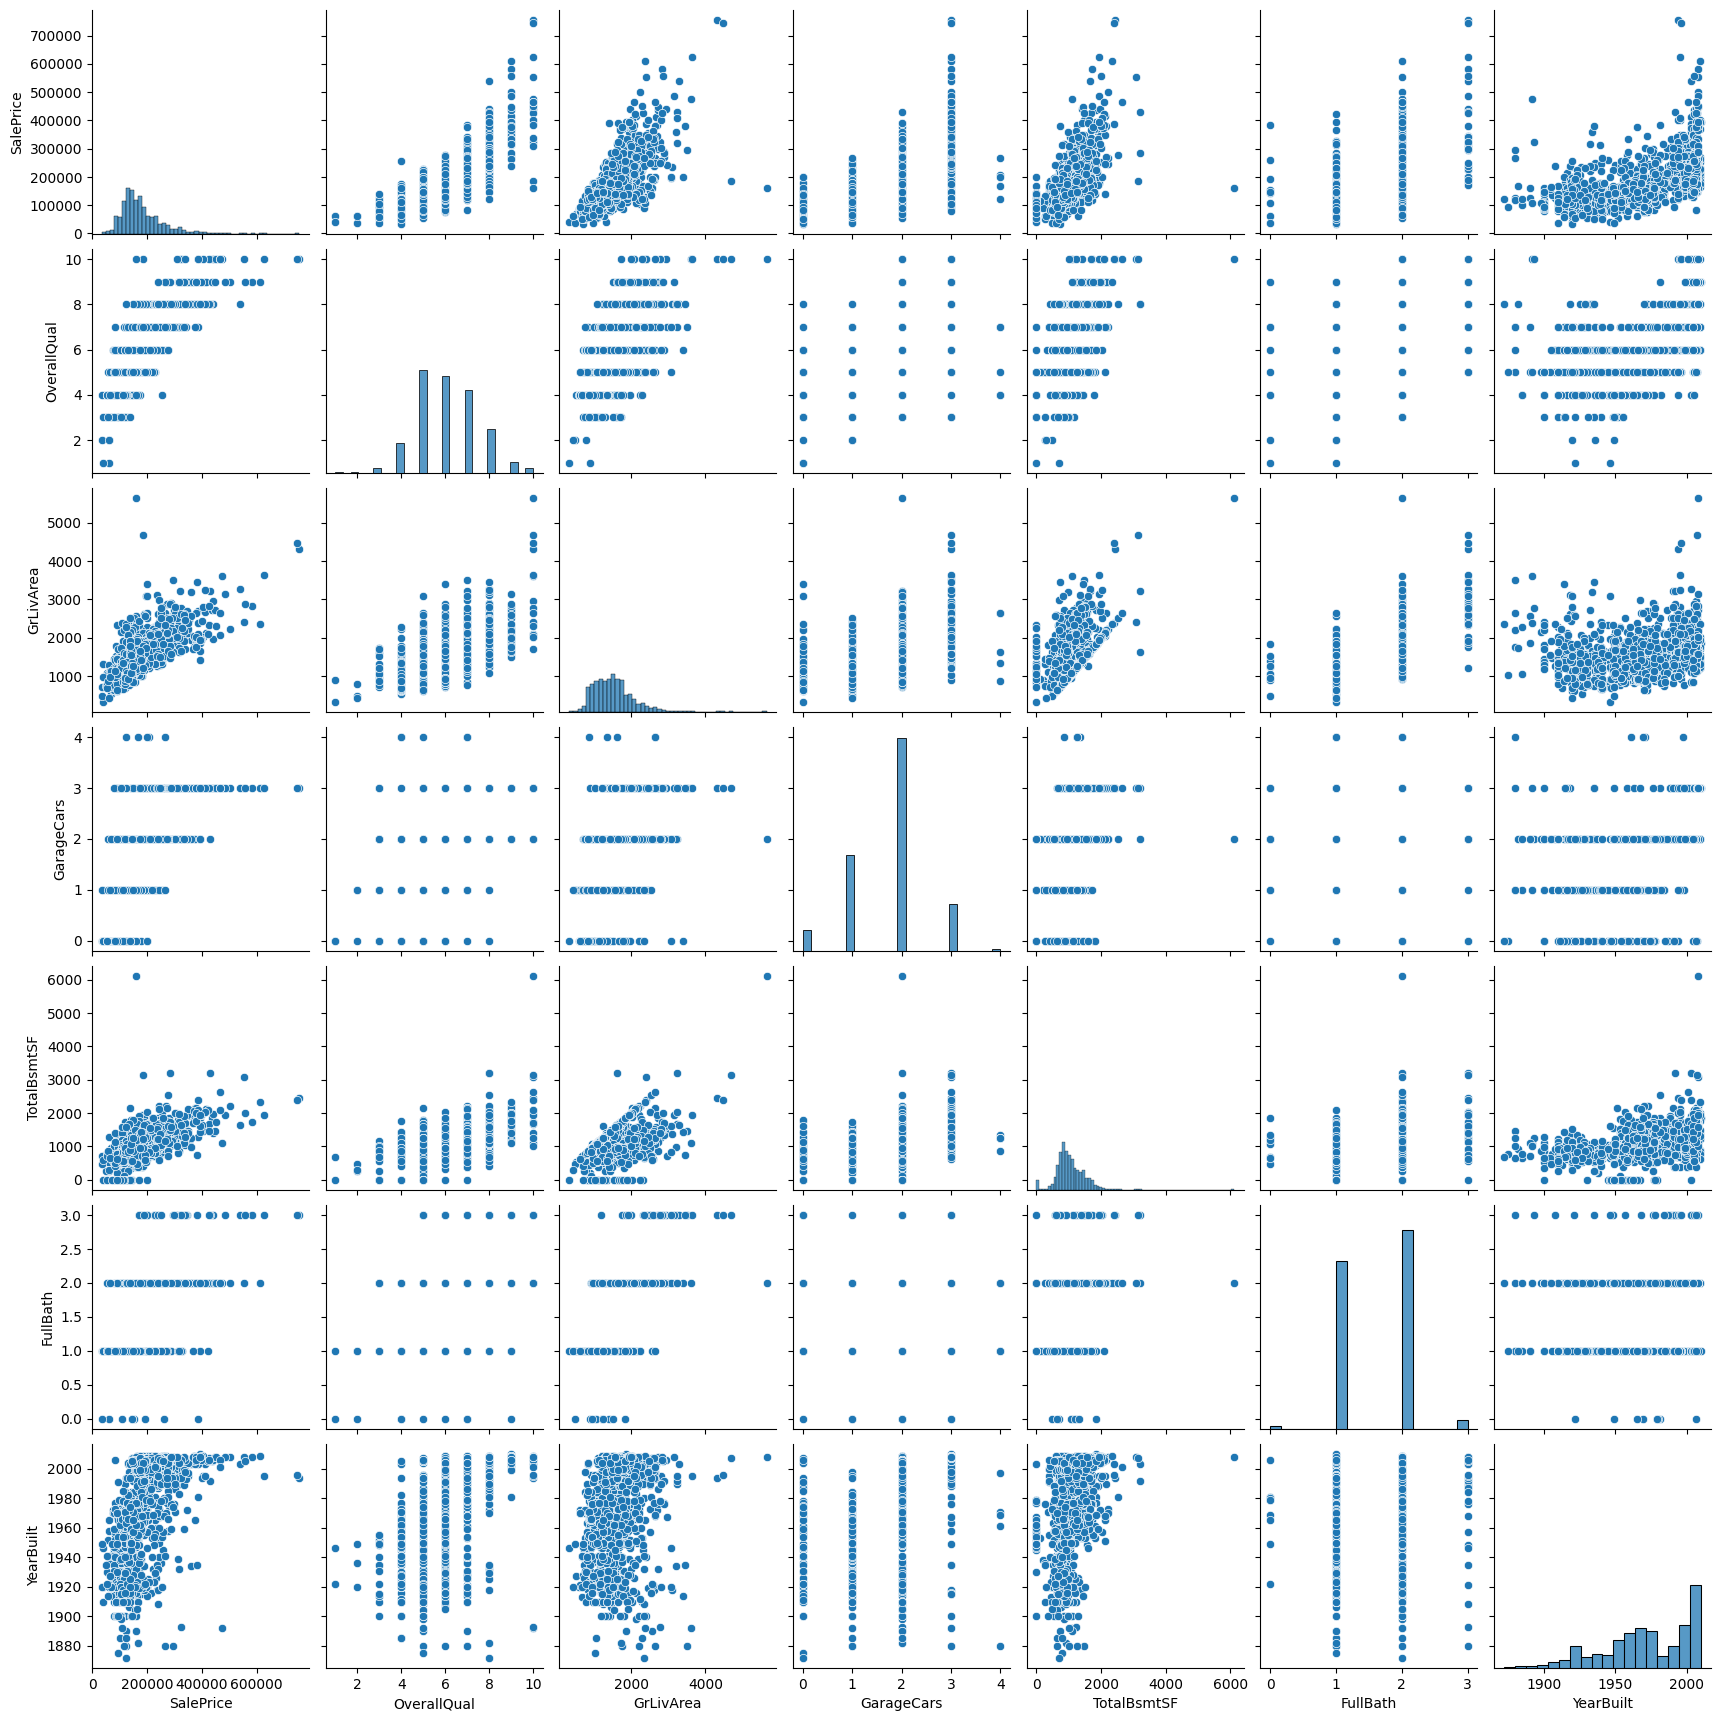

In [12]:
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_df[cols], height=2.5)
plt.show()

2〜3 で確認した傾向（`OverallQual` と価格の正の相関、`GrLivArea` の外れ値 2 件）は、pairplot 上でも同様に確認できる。

加えて、pairplot から以下の点が読み取れる。

- `YearBuilt` は新しいほど価格が高い傾向があるが、ばらつきが大きく、築年数だけでは価格を説明しきれない
- `FullBath` は 1 か 2 に集中しており、バスルーム数が増えるほど価格が高い傾向がある
- `YearBuilt` と `GrLivArea` の関係を見ると、新しい家ほど面積が大きい傾向が見られる。築年数と面積がある程度関連している可能性がある

## 5. 数値変数の歪度

目的変数の `SalePrice` は log変換で分布を整えたが、説明変数にも歪度が高い変数が残っている可能性がある。
歪度が大きい変数は、一部の極端な値にモデルが引っ張られやすくなるため、log変換の候補として洗い出す。

In [ ]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
skew_vals = train_df[numeric_cols].skew().sort_values(ascending=False)

# 歪度0.75以上を要注意として表示
skew_high = skew_vals[skew_vals > 0.75]
print("歪度が0.75以上の変数：")
print(skew_high)

歪度が0.75以上の変数：
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
dtype: float64


`MiscVal`（24.4）、`PoolArea`（14.8）、`LotArea`（12.2）など、歪度が極端に高い変数が多数ある。
これらは「ほとんどの家が 0 だが、極端に大きい値が少数存在する」タイプの変数である。

現在の `features` リストと照合すると、以下が log変換の検証候補として残っている。

- `LotArea`（歪度 12.2）
- `OpenPorchSF`（2.36）
- `BsmtFinSF1`（1.68）
- `WoodDeckSF`（1.54）
- `GrLivArea`（1.36）→ 既に log変換済み

これらの log変換が精度改善につながるかは、後続のノートブックで検証する。

## 6. 欠損値の確認

モデル学習の前に、欠損値の全体像を把握する。
このデータセットでは、欠損が「記録漏れ」を意味するケースと、「その設備が存在しない」ことを意味するケースが混在している。
ここでは各変数の欠損数・欠損率を確認し、前処理の方針を考える材料とする。

In [ ]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum() / len(train_df) * 100).sort_values(ascending=False)
missing_df = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
print(missing_df[missing_df['Total'] > 0])

              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageYrBlt      81   5.547945
GarageCond       81   5.547945
GarageType       81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
BsmtFinType2     38   2.602740
BsmtExposure     38   2.602740
BsmtQual         37   2.534247
BsmtCond         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


- `PoolQC`（99.5%）、`MiscFeature`（96.3%）、`Alley`（93.8%）、`Fence`（80.8%）は欠損率が非常に高い。
これらは大半の住宅で該当しない設備であり、モデルへの情報量は限定的と判断した。

- `LotFrontage` は約 17% が欠損しており、全体の中央値で一律に補完するか、地域ごとに補完するかで結果が変わる可能性がある。
7 の `Neighborhood` 別分析の結果も踏まえて、補完方針を `02_preprocessing.ipynb` で決定する。

- その他の欠損（`GarageType`、`BsmtQual` 等）は、設備が存在しないことを意味する欠損と、記録漏れによる欠損を区別して対応する必要がある。
具体的な補完処理は `02_preprocessing.ipynb` に記載する。

## 7. Neighborhood 別の SalePrice

不動産価格は立地に大きく左右される。
`Neighborhood`（地域）ごとに `SalePrice` の分布がどの程度異なるかを boxplot で確認し、立地情報を特徴量として活用する根拠を得る。

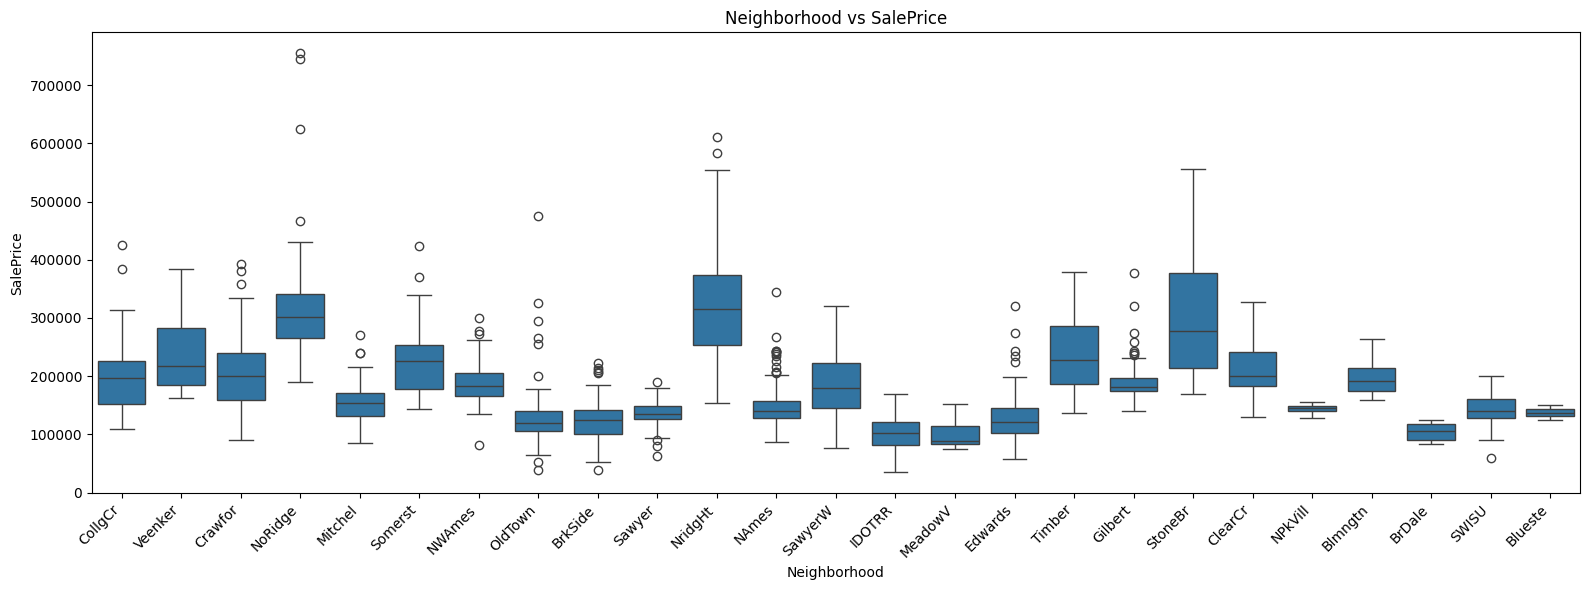

In [ ]:
plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train_df)
plt.xticks(rotation=45, ha='right')
plt.title('Neighborhood vs SalePrice')
plt.tight_layout()
plt.show()

- `NoRidge`、`NridgHt`、`StoneBr` が明らかに価格帯の高いエリアであり、`MeadowV`、`BrDale` が最も安いエリアである。
地域によって価格帯が大きく異なることが視覚的に確認でき、`Neighborhood` を数値化した Target Encoding（`Neighborhood_TE`）が有効に機能している理由が、この価格差の大きさから理解できる。

- エリア内のばらつきにも差があり、高価格帯の地域は四分位範囲が広い傾向がある。
このことから、`Neighborhood` 単体の数値化だけでなく、品質や面積との組み合わせでエリア内の価格差をより適切に表現できる可能性がある。

- 6 で確認した `LotFrontage` の欠損補完についても、この `Neighborhood` ごとの価格差を踏まえると、全体の中央値より `Neighborhood` 別の中央値で補完する方が実態に近いと考えられる。

## 8. Summary

本ノートブックでは、House Prices データセットに対して探索的データ分析を行い、前処理・特徴量設計の方針を決めるための知見を整理した。

### 主な発見

**目的変数 `SalePrice` の分布**
- 右に強く歪んだ分布（Skewness 1.88）であり、log変換で正規分布に近づくことを確認した

**`SalePrice` と強く相関する変数**
- `OverallQual`（0.79）、`GrLivArea`（0.71）が上位であり、品質と面積が価格予測の中心となる
- `GarageCars`、`GarageArea`、`TotalBsmtSF` も相関が高い

**外れ値**
- `GrLivArea` が 4000 超で価格が低い 2 件を複数の可視化で確認した
- `TotalBsmtSF` にも右端に 1 件の外れ値候補がある

**多重共線性**
- `GarageCars` × `GarageArea`（0.88）、`GrLivArea` × `TotRmsAbvGrd`（0.83）、`TotalBsmtSF` × `1stFlrSF`（0.82） に高い相関があり、情報の重複が確認された

**歪度の高い変数**
- `LotArea`、`OpenPorchSF`、`BsmtFinSF1`、`WoodDeckSF` が `features` の中で歪度が高く、log変換の検証候補として洗い出した

**欠損値**
- `PoolQC`、`MiscFeature`、`Alley`、`Fence` は欠損率が非常に高く、情報量は限定的と判断した
- `LotFrontage`（16% 欠損）は `Neighborhood` ごとの特性を踏まえて補完方針を決める必要がある

**`Neighborhood`**
- 地域によって価格帯が大きく異なり、`Neighborhood` の数値化（Target Encoding）が有効に機能する根拠を得た
- エリア内のばらつきの差から、品質・面積との組み合わせでさらに価格差を表現できる可能性がある

### 学び

本 EDA を通じて得た学びは以下の 3 点である。

- **数値と可視化を組み合わせて仮説を立てる。** → 相関係数だけでは外れ値や非線形性は見えない。散布図や boxplot で裏を取ることで、数字の背景にある構造が見えてくる
- **相関が高い＝有用な特徴量、とは限らない。** → `GarageCars` と `GarageArea` はどちらも `SalePrice` と相関が高いが、互いの相関も 0.88 と高い。変数単体の相関だけでなく、変数間の関係まで見て特徴量を選ぶ必要がある
- **EDA は仮説を立てる場であり、結論を出す場ではない。** → ここで発見した外れ値・歪度・多重共線性が実際にモデル精度に影響するかは、データの前処理やモデルの特性も含めて検証する必要がある